### PROTON THERAPY DESCRIPTIVE STATISTICS ###

In [10]:
import random as rd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load data
proton_dataset = pd.read_csv("Workload_UFHPTI2.csv")
proton_dataset.head()

,Date,Sessions,TxHours_subDelay,AvgFieldsPerPt,AvgLayersPerPt,AvgNumSpotsPerPt,Anesthesia,CSI,CSI or Anesthesia,BID,...,Thorax,Abdomen,CNS,Pelvis,Other,Spine,Month,Quarter,Year,Pacemaker
0,1/7/2020 0:00,17,8.532933,2.529412,19.019608,2347.009804,0,0,0,0,...,0,0,5,1,0,0,1,1,2020,0
1,1/13/2020 0:00,21,10.699600,2.619048,20.785714,2434.095238,0,0,0,0,...,0,0,6,1,0,0,1,1,2020,0
2,1/14/2020 0:00,21,9.649600,2.571429,20.357143,2280.626984,0,0,0,0,...,0,0,6,1,0,0,1,1,2020,0
3,1/15/2020 0:00,18,8.549600,2.555556,20.333333,2382.629630,0,0,0,0,...,0,0,5,1,0,0,1,1,2020,0
4,1/17/2020 0:00,17,8.166267,2.470588,20.568627,2323.147059,0,0,0,0,...,0,0,4,1,0,0,1,1,2020,0


In [4]:
# Checking for Missing Values:
proton_dataset.isnull().sum()

Date                 0
Sessions             0
TxHours_subDelay     0
AvgFieldsPerPt       0
AvgLayersPerPt       0
AvgNumSpotsPerPt     0
Anesthesia           0
CSI                  0
CSI or Anesthesia    0
BID                  0
TID                  0
Pediatric            0
HN                   0
Prostate             0
Brain                0
Breast               0
Bone                 0
Thorax               0
Abdomen              0
CNS                  0
Pelvis               0
Other                0
Spine                0
Month                0
Quarter              0
Year                 0
Pacemaker            0
dtype: int64

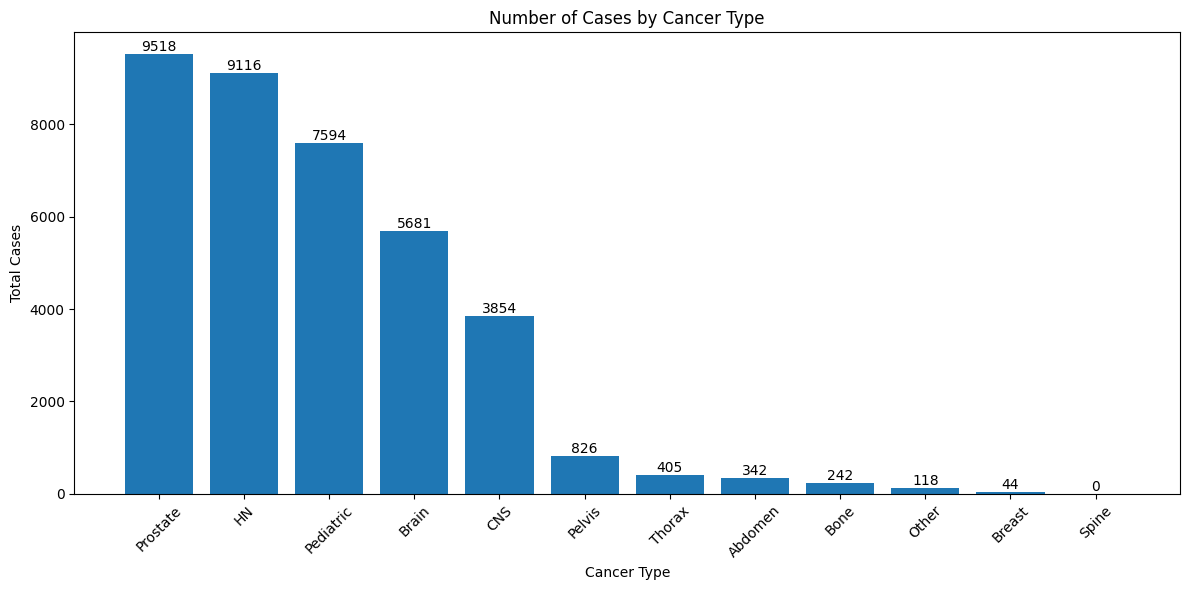

In [5]:

# Define cancer columns
cancer_cols = [
    "HN", "Prostate", "Brain", "Breast", "Bone",
    "Thorax", "Abdomen", "CNS", "Pelvis",
    "Other", "Spine", "Pediatric"
]

# Sum cases
cancer_counts = proton_dataset[cancer_cols].sum().sort_values(ascending=False)

# Create plot
plt.figure(figsize=(12, 6))
bars = plt.bar(cancer_counts.index, cancer_counts.values)

plt.title("Number of Cases by Cancer Type")
plt.ylabel("Total Cases")
plt.xlabel("Cancer Type")
plt.xticks(rotation=45)

# Add counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

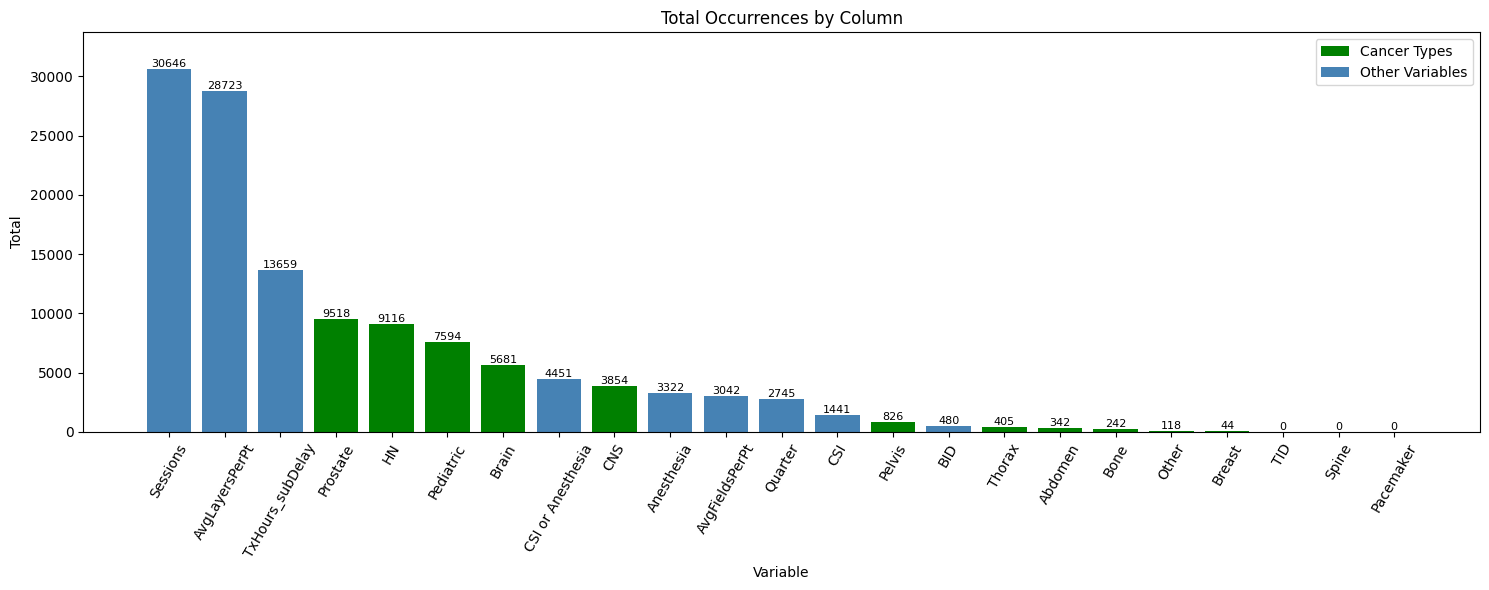

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Cancer columns
cancer_cols = [
    "HN", "Prostate", "Brain", "Breast", "Bone",
    "Thorax", "Abdomen", "CNS", "Pelvis",
    "Other", "Spine", "Pediatric"
]

# Select numeric columns
numeric_cols = proton_dataset.select_dtypes(include='number')

# Drop unwanted columns
cols_to_drop = ["AvgNumSpotsPerPt", "Year", "Month"]
filtered_cols = numeric_cols.drop(columns=cols_to_drop, errors="ignore")

# Sum each column
counts = filtered_cols.sum().sort_values(ascending=False)

# Assign colors (green for cancer types)
colors = [
    "green" if col in cancer_cols else "steelblue"
    for col in counts.index
]

# Plot
plt.figure(figsize=(15, 6))
bars = plt.bar(counts.index, counts.values, color=colors)

plt.title("Total Occurrences by Column")
plt.ylabel("Total")
plt.xlabel("Variable")
plt.xticks(rotation=60)

# Add counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=8
    )

# Legend
legend_elements = [
    Patch(facecolor='green', label='Cancer Types'),
    Patch(facecolor='steelblue', label='Other Variables')
]
plt.legend(handles=legend_elements)

# Add headroom
plt.ylim(0, counts.max() * 1.1)

plt.tight_layout()
plt.show()

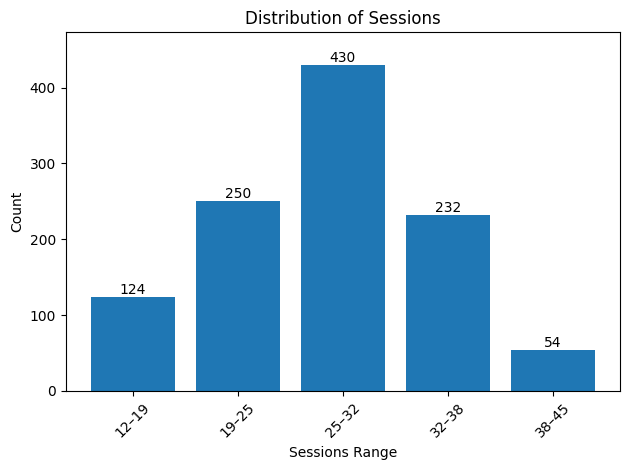

In [7]:
# Create 5 equal-width bins
proton_dataset["Sessions_Bin"] = pd.cut(
    proton_dataset["Sessions"],
    bins=5
)

# Count how many in each bin
bin_counts = proton_dataset["Sessions_Bin"].value_counts().sort_index()

# Convert interval labels into cleaner strings
clean_labels = [
    f"{int(interval.left)}–{int(interval.right)}"
    for interval in bin_counts.index
]

# Plot
plt.figure()
bars = plt.bar(clean_labels, bin_counts.values)

plt.xticks(rotation=45)
plt.title("Distribution of Sessions")
plt.xlabel("Sessions Range")
plt.ylabel("Count")

# Add counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

# Add headroom so labels don’t get cut off
plt.ylim(0, max(bin_counts.values) * 1.1)

plt.tight_layout()
plt.show()


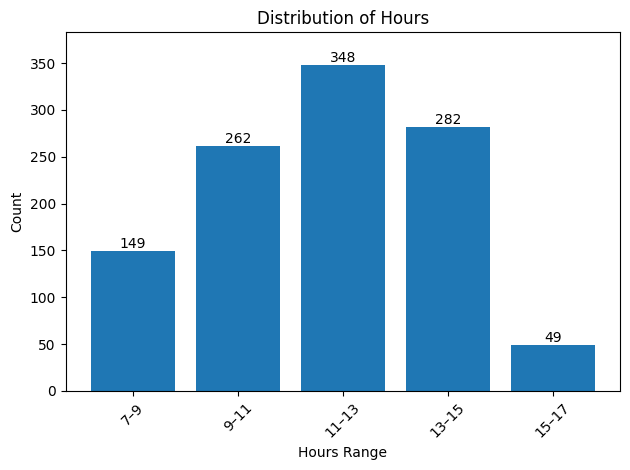

In [8]:
# Create 5 equal-width bins
proton_dataset["Hours_Bins"] = pd.cut(
    proton_dataset["TxHours_subDelay"],
    bins=5
)

# Count how many in each bin
bin_counts = proton_dataset["Hours_Bins"].value_counts().sort_index()

# Convert interval labels into cleaner strings
clean_labels = [
    f"{int(interval.left)}–{int(interval.right)}"
    for interval in bin_counts.index
]

# Plot
plt.figure()
bars = plt.bar(clean_labels, bin_counts.values)

plt.xticks(rotation=45)
plt.title("Distribution of Hours")
plt.xlabel("Hours Range")
plt.ylabel("Count")

# Add counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

# Add headroom so labels don’t get cut off
plt.ylim(0, max(bin_counts.values) * 1.1)

plt.tight_layout()
plt.show()


In [9]:
# Dropping non-numeric column (dates)
proton_dataset = pd.read_csv("Workload_UFHPTI2.csv")
df_proton = proton_dataset.drop(columns=["Date"])

# Keep only numeric columns
df_numeric = df_proton.select_dtypes(include="number")

# Compute statistics
summary_stats = pd.DataFrame({
    "Mean": df_numeric.mean(),
    "Median": df_numeric.median(),
    "Variance": df_numeric.var()
})

print(summary_stats)

                          Mean       Median      Variance
Sessions             28.115596    29.000000  4.535853e+01
TxHours_subDelay     12.531863    12.716267  4.328009e+00
AvgFieldsPerPt        2.791637     2.800000  3.420031e-02
AvgLayersPerPt       26.351947    26.291667  3.592201e+00
AvgNumSpotsPerPt   4859.160605  4807.807059  1.299994e+06
Anesthesia            3.047706     3.000000  4.243819e+00
CSI                   1.322018     1.000000  1.586751e+00
CSI or Anesthesia     4.083486     4.000000  5.793758e+00
BID                   0.440367     0.000000  5.019503e-01
TID                   0.000000     0.000000  0.000000e+00
Pediatric             6.966972     7.000000  8.233986e+00
HN                    8.363303     8.000000  9.509763e+00
Prostate              8.732110     9.000000  3.209713e+01
Brain                 5.211927     5.000000  6.828324e+00
Breast                0.040367     0.000000  3.877305e-02
Bone                  0.222018     0.000000  1.912503e-01
Thorax        

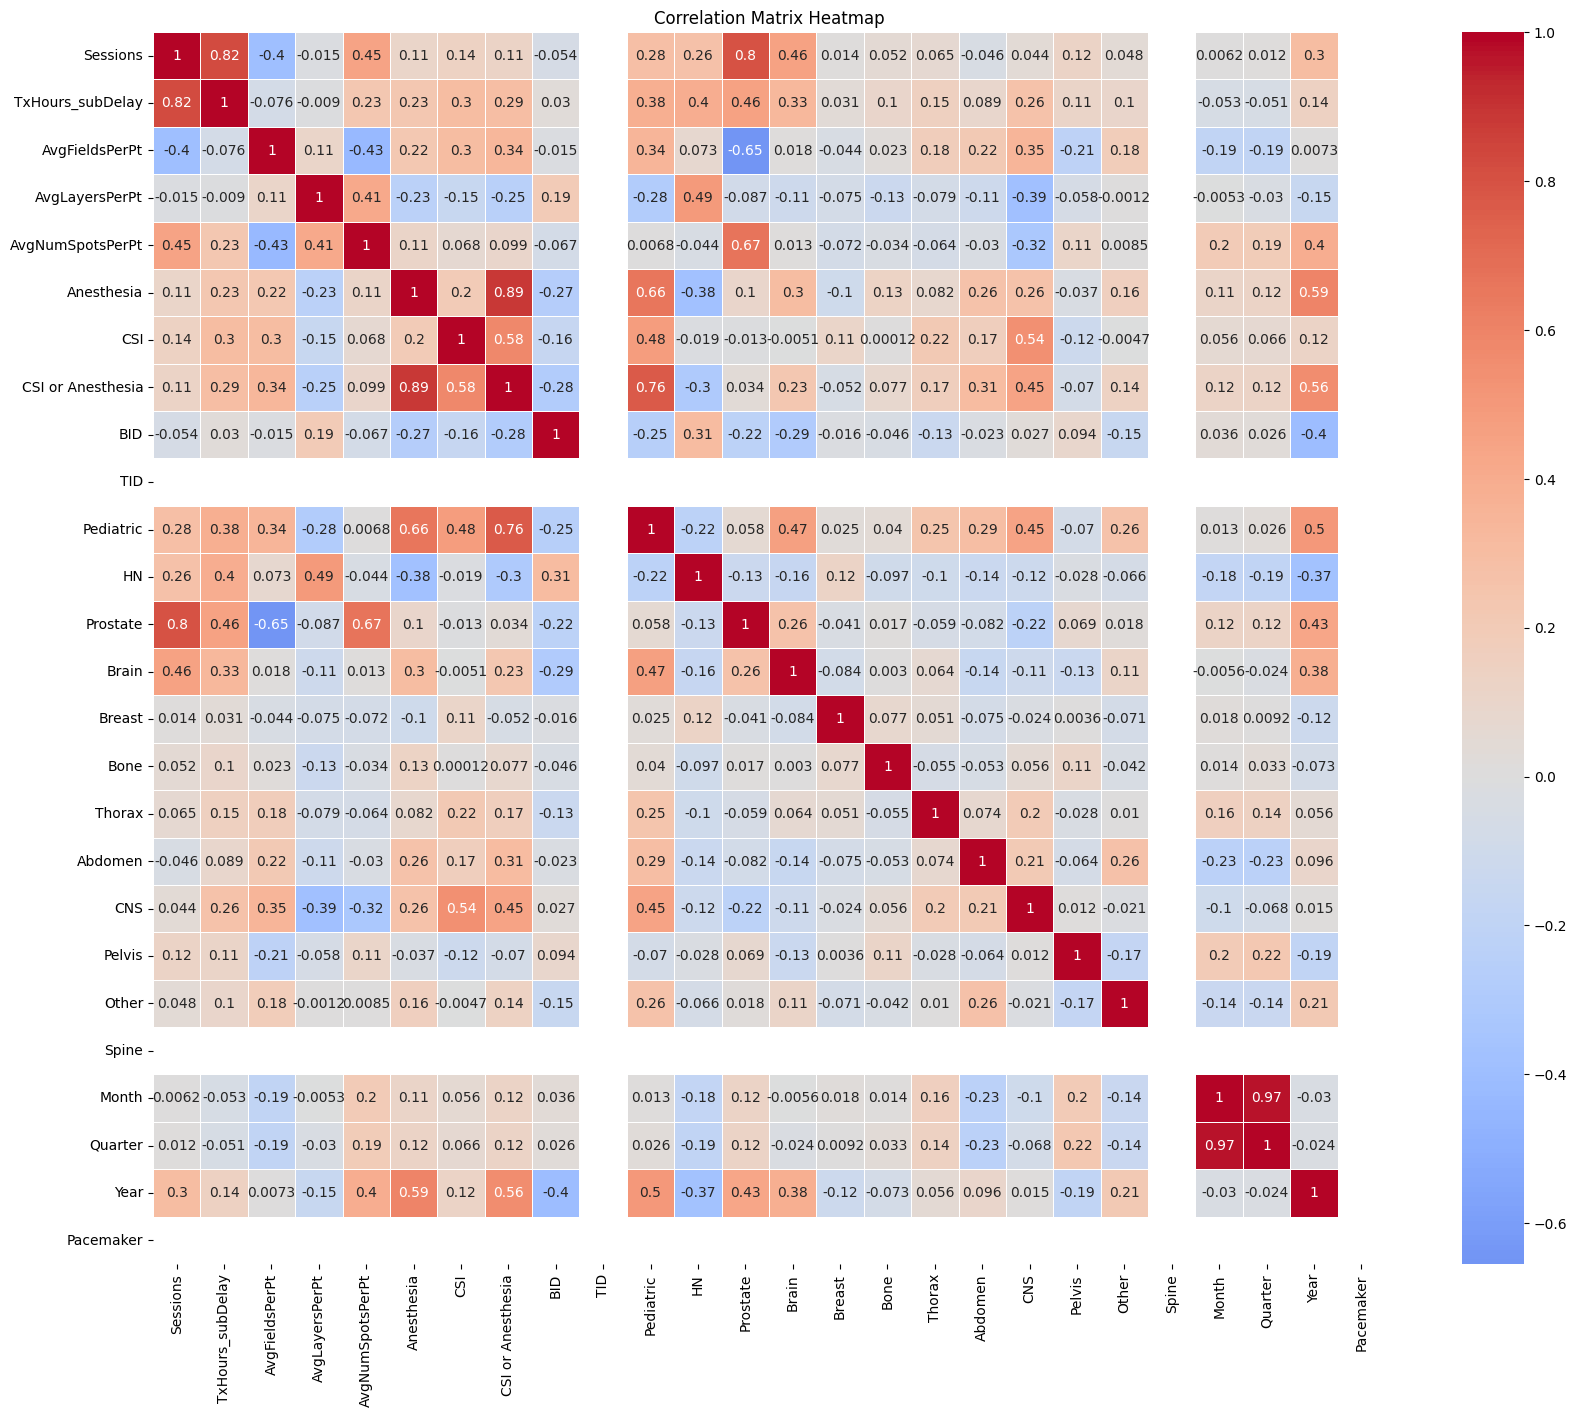

In [11]:
# Correlation Matrix to see Relationship between Variables:
corr_matrix = df_proton.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

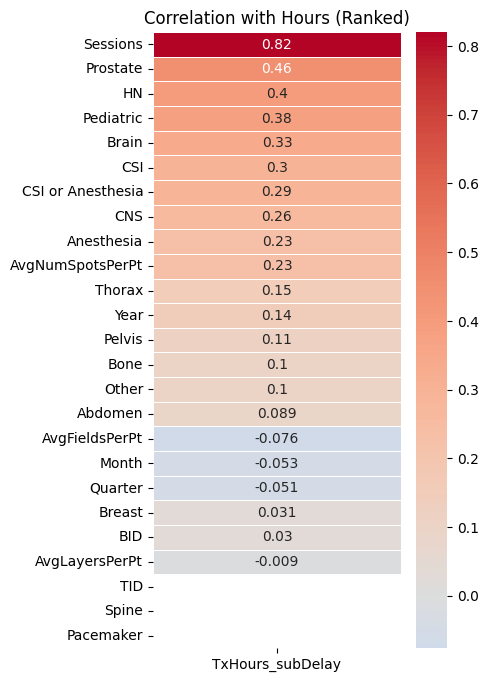

In [12]:
# Correlation of all variables with 'hours'
hours_corr = df_proton.corr()[["TxHours_subDelay"]]

# Remove self-correlation
hours_corr = hours_corr.drop("TxHours_subDelay")

# Sort by absolute correlation (strongest first)
hours_corr_sorted = hours_corr.reindex(
    hours_corr["TxHours_subDelay"].abs().sort_values(ascending=False).index
)

plt.figure(figsize=(4, 8))
sns.heatmap(
    hours_corr_sorted,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation with Hours (Ranked)")
plt.show()